**Import dependencies**

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from scipy.linalg import svdvals
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import pairwise_distances
import os


**Load data**

In [2]:
io_data = pd.read_csv("tau_log.csv")

# put 'label' as the row index
io_data = io_data.set_index("label")

# keep only the time columns (they look like t0.0, t0.1, ..., etc.)
time_cols = [c for c in io_data.columns if c.startswith("t")]

# numeric sort for rows like 'tau_cmd_0', 'tau_cmd_1', ...
def row_sort_key(s):
    m = re.search(r"_(\d+)$", s)
    return int(m.group(1)) if m else 10**9

# select and sort the commanded torques (u) and external torques (y)
u_rows = sorted([r for r in io_data.index if r.startswith("tau_cmd")], key=row_sort_key)
y_rows = sorted([r for r in io_data.index if r.startswith("tau_ext")], key=row_sort_key)

# build arrays (first column is just 0.0)
u_data = io_data.loc[u_rows, time_cols].to_numpy()[:, :-1].T # remove last column to align with y
y_data = io_data.loc[y_rows, time_cols].to_numpy()[:, 1:].T # remove first column to align with u



**Build Hankel Matrix**

In [3]:
m = u_data.shape[1] # Input dimension
p = y_data.shape[1] # Output dimension
N = u_data.shape[0] # Length of data

T_past = 40 # Past horizon
T_future = 8 # Future horizon
L = T_past + T_future # Total horizon

cols = N-L+1 # nummber of columns in Hankel matrix

# Initialize Hankel matrices
Hu = u_data[:L, :].reshape(m*L,1)
Hy = y_data[:L, :].reshape(p*L,1)
# rank_Hankel = [np.linalg.matrix_rank(np.vstack([Hu, Hy]))]

# Construct Hankel matrices
Hu_list = []
Hy_list = []
for i in range(1, cols):
    Hu_list.append(u_data[i:i+L, :].reshape(m*L,1))
    Hy_list.append(y_data[i:i+L, :].reshape(p*L,1))

Hu = np.hstack(Hu_list)
Hy = np.hstack(Hy_list)

# Split Hankel matrices into past and future
Hu_past = Hu[:m*T_past, :]
Hu_future = Hu[-m*T_future:, :]
Hy_past = Hy[:p*T_past, :]
Hy_future = Hy[-p*T_future:, :]

print(Hu_past.shape)
print(Hu_future.shape)
print(Hy_past.shape)
print(Hy_future.shape)

(280, 77484)
(56, 77484)
(280, 77484)
(56, 77484)


**Hankel matrix analysis**

/tmp/ipykernel_75372/394385485.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


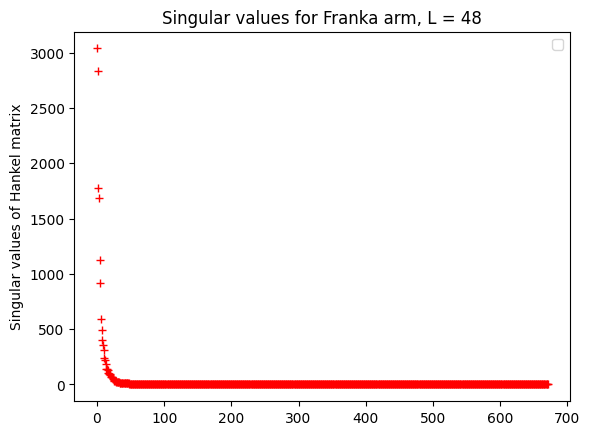

672


'\n# Plot to check what rank Hankel matrix reached\nplt.plot(range(cols), rank_Hankel)\nplt.xlabel(\'Number of Columns\')\nplt.ylabel(\'Hankel Matrix Rank\')\nplt.title(f\'Hankel for Franka arm, L = {L}\')\nplt.xticks(\n    np.arange(0, cols, 40),\n    np.arange(1, cols+1, 40)\n)\nplt.yticks(np.arange(1, rank_Hankel[-1], 40))\nplt.show()\nprint("Hankel_rank: ", rank_Hankel[-1])\n'

In [4]:
# Plot singular values
H = np.vstack((Hu,Hy))
singular_values = svdvals(H)
plt.plot(singular_values,'r+')
plt.ylabel('Singular values of Hankel matrix')
plt.title(f'Singular values for Franka arm, L = {L}')
plt.legend()
plt.show()

print(np.linalg.matrix_rank(H))

"""
# Plot to check what rank Hankel matrix reached
plt.plot(range(cols), rank_Hankel)
plt.xlabel('Number of Columns')
plt.ylabel('Hankel Matrix Rank')
plt.title(f'Hankel for Franka arm, L = {L}')
plt.xticks(
    np.arange(0, cols, 40),
    np.arange(1, cols+1, 40)
)
plt.yticks(np.arange(1, rank_Hankel[-1], 40))
plt.show()
print("Hankel_rank: ", rank_Hankel[-1])
"""

**Sampling the Hankel matrix**

In [ ]:
# Full Hankel matrix
X = np.vstack((Hu_past, Hy_past, Hu_future))

# Normalize the data
row_mean = X.mean(axis=1, keepdims=True)
row_norm  = X.std(axis=1, keepdims=True) + 1e-8
X_norm = (X - row_mean) / row_norm

X_samples = X_norm.T 

# K-means clustering
m = 1000
kmeans = MiniBatchKMeans(
    n_clusters=m,
    batch_size=4096,
    max_iter=200,
    n_init='auto',
    random_state=0,
    verbose=0
)

kmeans.fit(X_samples)

centers = kmeans.cluster_centers_
nearest_idx, _ = pairwise_distances_argmin_min(centers, X_samples)

S = np.sort(nearest_idx)

Hu_past_sub = Hu_past[:, S]
Hy_past_sub = Hy_past[:, S]
Hu_future_sub = Hu_future[:, S]
Hy_future_sub = Hy_future[:, S]

X_sub = np.vstack((Hu_past_sub, Hy_past_sub, Hu_future_sub)) # shape = (d, Hc_sub)


**Clusters plot**

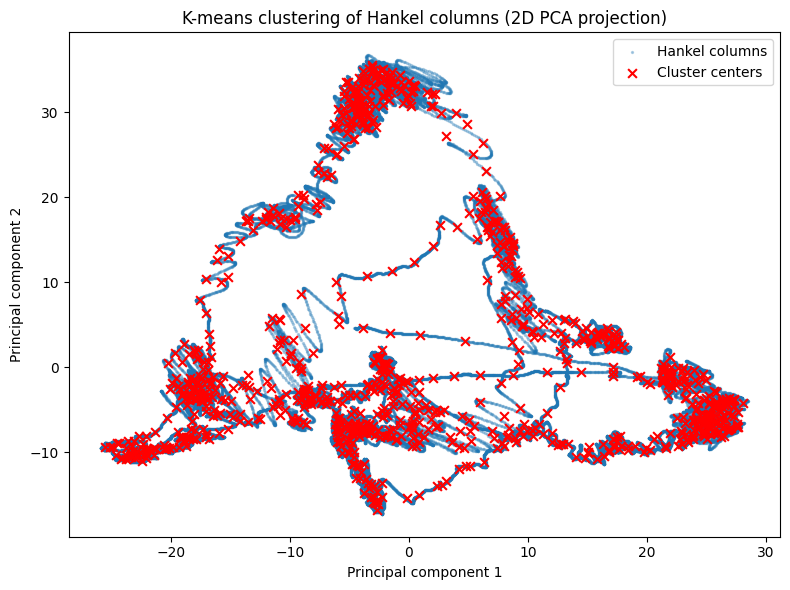

In [6]:
pca = PCA(n_components=2, random_state=0)
X_2d = pca.fit_transform(X_samples)
centers_2d = pca.transform(centers)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=2, alpha=0.3, label='Hankel columns')
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='red', s=40, marker='x', label='Cluster centers')

plt.title('K-means clustering of Hankel columns (2D PCA projection)')
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.legend()
plt.tight_layout()
plt.show()

**Plot metrics for sampled Hankel Matrix**

/tmp/ipykernel_75372/3528110074.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


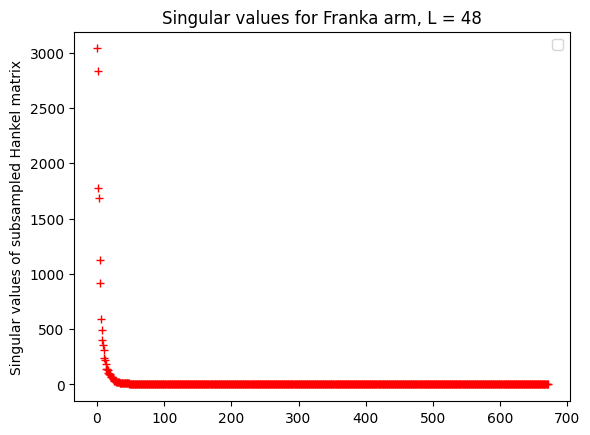

672


In [7]:
# Plot singular values
H_sub = np.vstack((Hu_past_sub,Hu_future_sub,Hy_past_sub,Hy_future_sub))
singular_values = svdvals(H)
plt.plot(singular_values,'r+')
plt.ylabel('Singular values of subsampled Hankel matrix')
plt.title(f'Singular values for Franka arm, L = {L}')
plt.legend()
plt.show()

print(np.linalg.matrix_rank(H_sub))

**Kernel matrix**

In [ ]:
"""
X_samples = X_sub.T  # each row = one trajectory (column of Hankel)

# Choose kernel width (median heuristic)
pairwise_dists = pairwise_distances(X_samples)
sigma = np.median(pairwise_dists)
gamma = 1 / (2 * sigma**2)

# Compute Gram (kernel) matrix
K = rbf_kernel(X_samples, X_samples, gamma=gamma)  # shape (Hc_sub, Hc_sub)
print(K.shape)
"""

Chosen RBF kernel gamma: 0.0007895572012316172
(1000, 1000)


**Gridsearch to find best parameters for Kernel and regularization**

In [24]:
X1_full = np.vstack([Hu_past_sub, Hy_past_sub]) # shape (d1, Hc_sub)
X2_full = Hu_future_sub # shape (d2, Hc_sub)
YF_full = Hy_future_sub # shape (pN, Hc_sub)

Hc = X1_full.shape[1]

# Train/Validation split over columns 
rng = np.random.default_rng(0)
perm = rng.permutation(Hc)
train_ratio = 0.8
n_tr = int(train_ratio * Hc)
idx_tr, idx_va = perm[:n_tr], perm[n_tr:]

X1_tr, X1_va = X1_full[:, idx_tr], X1_full[:, idx_va]
X2_tr, X2_va = X2_full[:, idx_tr], X2_full[:, idx_va]
YF_tr, YF_va = YF_full[:, idx_tr], YF_full[:, idx_va]

# Row-wise standardization on Training-set
def standardize_rows(A, mean=None, std=None):
    if mean is None:
        mean = A.mean(axis=1, keepdims=True)
    if std is None:
        std = A.std(axis=1, keepdims=True)
    std = std + 1e-8
    return (A - mean) / std, mean, std

X1_tr_std, row_mean_X1, row_std_X1 = standardize_rows(X1_tr)
X1_va_std, _, _ = standardize_rows(X1_va, row_mean_X1, row_std_X1)
X2_tr = X2_tr
X2_va = X2_va
YF_tr = YF_tr
YF_va = YF_va

# Mixed Kernel: RBF on X1, Linear on X2
def mixed_kernel_gram(X1A, X2A, X1B, X2B, gamma_rbf):
    K_rbf = rbf_kernel(X1A.T, X1B.T, gamma=gamma_rbf)
    K_lin = X2A.T @ X2B
    return K_rbf + K_lin

# Sigma grid (centered at median pairwise dist on training set, X1 space)
pd_tr = pairwise_distances(X1_tr_std.T, metric='euclidean')
tri = np.triu_indices_from(pd_tr, k=1)
sigma_med = np.median(pd_tr[tri]) if tri[0].size > 0 else np.median(pd_tr)
sigma_grid = (sigma_med * (10.0 ** np.linspace(-3, 3, 21))) if (np.isfinite(sigma_med) and sigma_med > 0) else np.logspace(-3, 3, 21)

# lambda grid scaled to kernel magnitude at a reference sigma
ref_sigma = float(sigma_grid[len(sigma_grid)//2])
ref_gamma = 1.0 / (2.0 * ref_sigma**2)
Ktr_ref = mixed_kernel_gram(X1_tr_std, X2_tr, X1_tr_std, X2_tr, ref_gamma)
lam_scale = float(np.mean(np.diag(Ktr_ref)))
lambda_grid = lam_scale * (10.0 ** np.linspace(-8, -1, 8))

best = {"mse": np.inf, "sigma": None, "lambda": None}

# Grid search over (sigma, lambda_reg)
for sigma in sigma_grid:
    gamma_rbf = 1.0 / (2.0 * sigma**2)
    K_tr = mixed_kernel_gram(X1_tr_std, X2_tr, X1_tr_std, X2_tr, gamma_rbf) # (n_tr, n_tr)
    K_tr_va = mixed_kernel_gram(X1_tr_std, X2_tr, X1_va_std, X2_va, gamma_rbf) # (n_tr, n_va)

    for lam in lambda_grid:
        Kreg = K_tr + lam * np.eye(K_tr.shape[0], dtype=K_tr.dtype)
        inv_times_cross = np.linalg.solve(Kreg, K_tr_va) # (n_tr, n_va)
        Y_pred_va = YF_tr @ inv_times_cross # (pN, n_va)
        mse = float(np.mean((Y_pred_va - YF_va) ** 2))

        if mse < best["mse"]:
            best.update({"mse": mse, "sigma": float(sigma), "lambda": float(lam)})

print(f"best sigma={best['sigma']:.6g}, best lambda={best['lambda']:.3e}, MSE={best['mse']:.6g}")

best_gamma_rbf = 1.0 / (2.0 * best['sigma']**2)
print("Best gamma_rbf:", best_gamma_rbf)



best sigma=267.635, best lambda=4.738e-07, MSE=0.000820995
Best gamma_rbf: 6.9804411431685434e-06


**Build Kernel Gram Matrix**

In [25]:
X_samples = X_sub.T

K = rbf_kernel(X_samples, X_samples, gamma=best_gamma_rbf)  # shape (Hc_sub, Hc_sub)
print(K.shape)


(1000, 1000)


** Export all relevant objects**

In [27]:
save_dict = {
    "K": K.astype(np.float32),
    "X": X_sub.astype(np.float32),
    "Hy_future": Hy_future_sub.astype(np.float32),
    "gamma": np.array(best["lambda"], dtype=np.float32),
    "rbf_scale": np.array(best_gamma_rbf, dtype=np.float32),
}

out_path = os.path.join(os.getcwd(), "kernel_deepc_bundle.npz")
np.savez_compressed(out_path, **save_dict)

print(f"Bundle written to: {out_path}")
print("Contents:", list(save_dict.keys()))

Bundle written to: /home/anthony-ho/franka_ros2_ws/src/nonlinear_deepc_controller/data_processing/kernel_deepc_bundle.npz
Contents: ['K', 'X', 'Hy_future', 'gamma', 'rbf_scale']
